In [65]:
import geopandas as gpd
import random
from shapely.geometry import Point

In [68]:
gdf = gpd.read_file("../data/gis/mavfa-fs-3000_zone.shp")

# 2. Imposta CRS (se manca)
gdf = gdf.set_crs("EPSG:4326")

# (opzionale ma consigliato) lavora in metri
gdf = gdf.to_crs("EPSG:3857")

In [69]:
gdf

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
0,SM,Repubblica di San Marino,99.0,Manual insert,3000.0,43.938325,12.463315,"POLYGON ((1381661.356 5455993.767, 1381510.997..."
1,VA,Città del Vaticano,58.0,Manual insert,3000.0,41.903445,12.453023,"POLYGON ((1385547.304 5146372.177, 1385573.704..."
2,5010,Napoli - 11,63.0,napoli,3000.0,40.847021,14.267001,"POLYGON ((1589175.012 4989479.393, 1589020.668..."
3,10010041002,Varallo,2.0,CESPI,3000.0,45.820946,8.246350,"POLYGON ((909150.623 5744537.569, 909126.578 5..."
4,10010041003,Balmuccia,2.0,CESPI,3000.0,45.772575,8.038943,"POLYGON ((897729.577 5747578.263, 897747.054 5..."
...,...,...,...,...,...,...,...,...
2975,3049,Latino,58.0,roma,3000.0,41.875260,12.521160,"POLYGON ((1394026.429 5144373.326, 1394031.257..."
2976,6020,Padova,15.0,milano,3000.0,45.504990,9.224978,"POLYGON ((1028181.236 5698380.806, 1028005.969..."
2977,6021,Buenos Aires - Venezia,15.0,milano,3000.0,45.477025,9.214489,"POLYGON ((1025838.126 5698430.314, 1025917.316..."
2978,6040,Parco delle Abbazie,15.0,milano,3000.0,45.418270,9.197160,"POLYGON ((1025306.253 5684216.282, 1025295.095..."


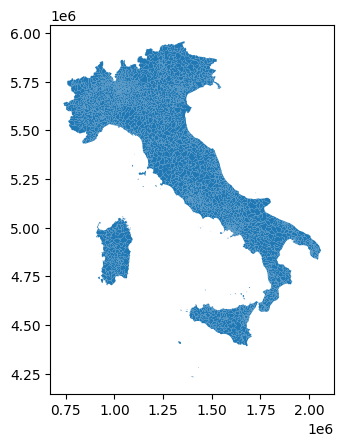

In [70]:
gdf.plot();

In [71]:
firenze_centro_storico = gdf[gdf.zone_name == 'Firenze Centro Storico']
firenze_centro_storico = firenze_centro_storico.to_crs("EPSG:4326")
firenze_centro_storico

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2657,1009006000,Firenze Centro Storico,48.0,citta_metro,3000.0,43.761575,11.233814,"POLYGON ((11.30134 43.76433, 11.30338 43.76379..."


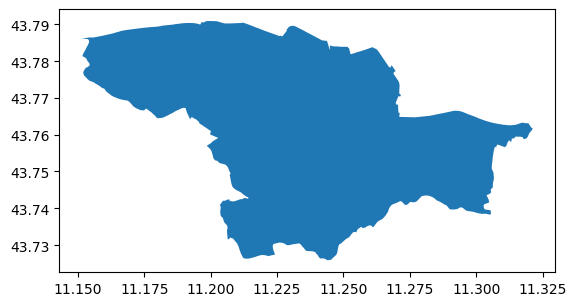

In [72]:
firenze_centro_storico.plot();

In [73]:
gdf[gdf.zone_name == 'Campo di Marte']

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2659,1009006002,Campo di Marte,48.0,citta_metro,3000.0,43.789761,11.293229,"POLYGON ((1256521.429 5439375.888, 1256522.428..."


In [74]:

# 4. Funzione per punto casuale
def random_point_in_polygon(polygon):
    minx, miny, maxx, maxy = polygon.bounds
    
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            return p

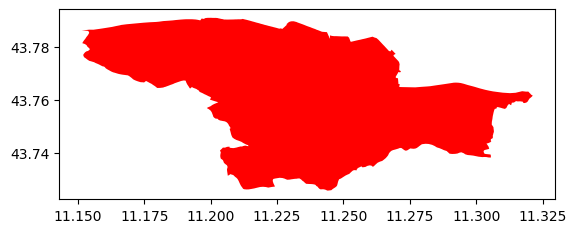

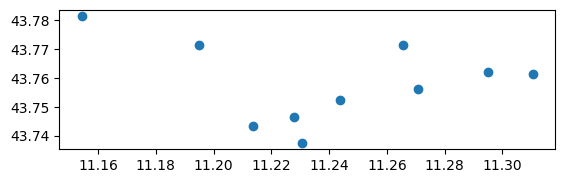

In [94]:

# 3. Scegli una geometria (es: zona trovata prima)
geom = gdf.geometry.iloc[10]
geom = firenze_centro_storico.geometry.iloc[0]
# 5. Genera N punti
N = 10
points = [random_point_in_polygon(geom) for _ in range(N)]

# 6. Crea GeoDataFrame dei punti
points_gdf = gpd.GeoDataFrame(geometry=points, crs=gdf.crs)

# 7. Visualizza
#ax = gdf.plot(color="lightgrey", figsize=(6,6))
gpd.GeoSeries([geom]).plot( color="red")
points_gdf.plot();